In [1]:
!conda install -c conda-forge scikit-surprise -y

Solving environment: ...working... done

# All requested packages already installed.

Retrieving notices: ...working... done




==> WARNING: A newer version of conda exists. <==
  current version: 4.14.0
  latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import Dataset, Reader, KNNBasic, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy as surprise_accuracy
from sklearn.preprocessing import MultiLabelBinarizer
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

In [3]:
movies_original = pd.read_csv('movies.csv')
ratings_train_original = pd.read_csv('ratings_train.csv')
ratings_test_original = pd.read_csv('ratings_test.csv')

In [4]:
movies = movies_original.copy()
ratings_train = ratings_train_original.copy()
ratings_test = ratings_test_original.copy()

# **Head dataframe**

In [5]:
movies_original.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings_train_original.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
ratings_train_original.sort_values(by='movieId')

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
65957,436,1,4.0,833529571
66185,438,1,4.5,1105650469
11647,73,1,4.5,1464196374
11568,71,1,5.0,864737933
...,...,...,...,...
27074,184,193581,4.0,1537109082
27075,184,193583,3.5,1537109545
27076,184,193585,3.5,1537109805
27077,184,193587,3.5,1537110021


In [8]:
ratings_test_original.head()

,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#load data

n_movies = movies['movieId'].nunique()
n_users = ratings_train['userId'].nunique()
n_movies_rated = ratings_train['movieId'].nunique()
print(f"Movies: {n_movies}")
print(f"Users: {n_users}")
print(f"ratings_train: {ratings_train.shape}")
print(f"Rated movies: {n_movies_rated}")
print(f"Rating range: {ratings_train['rating'].min()} – {ratings_train['rating'].max()}")

Movies: 9742
Users: 600
ratings_train: (97801, 4)
Rated movies: 9680
Rating range: 0.5 – 5.0


In [10]:
#list of genres

movies["genres"].fillna("Nan")
genres_list = movies["genres"].str.split("|")
flatten_list=np.concatenate(genres_list).tolist()
flatten_list=list(set(flatten_list))
flatten_list.sort()
print(f"List of genres({len(flatten_list)}):\n")
for i in flatten_list:
    print(f"*{i}")

List of genres(20):

*(no genres listed)
*Action
*Adventure
*Animation
*Children
*Comedy
*Crime
*Documentary
*Drama
*Fantasy
*Film-Noir
*Horror
*IMAX
*Musical
*Mystery
*Romance
*Sci-Fi
*Thriller
*War
*Western


# **Preprocessing**

In [11]:
#preprocess movies.csv

#extract year from title
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)$", expand=False)
movies["title_clean"] = movies["title"].str.replace(r"\s*\(\d{4}\)$", "", regex=True).str.strip()

#handle missing year
missing_year_count = movies["year"].isna().sum()
movies["year"] = movies["year"].fillna("Unknown")
print(f"\n Filled {missing_year_count} missing years with: 'Unknown'")

#handle "(no genres listed)"(only way to indicate that a film has no genres, see cell above)
no_genre_count = (movies["genres"] == "(no genres listed)").sum()
movies["genres"] = movies["genres"].replace("(no genres listed)", "Unknown")
print(f" Replaced {no_genre_count} '(no genres listed)' with 'Unknown'")

#extract genres and create matrix
movies["genres_list"] = movies["genres"].str.split("|")
mlb = MultiLabelBinarizer()
genres_matrix = mlb.fit_transform(movies["genres_list"])
genres_df = pd.DataFrame(genres_matrix, columns=mlb.classes_, index=movies.index)

movies_encoded = pd.concat([movies.drop(columns=["genres_list","title","genres"]), genres_df], axis=1)

display(genres_df)
display(movies_encoded)


 Filled 24 missing years with: 'Unknown'
 Replaced 34 '(no genres listed)' with 'Unknown'


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,Unknown,War,Western
0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
9738,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
9739,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
9740,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,movieId,year,title_clean,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,Unknown,War,Western
0,1,1995,Toy Story,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1995,Jumanji,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1995,Grumpier Old Men,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,4,1995,Waiting to Exhale,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,5,1995,Father of the Bride Part II,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,193581,2017,Black Butler: Book of the Atlantic,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9738,193583,2017,No Game No Life: Zero,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9739,193585,2017,Flint,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9740,193587,2018,Bungo Stray Dogs: Dead Apple,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
#preprocess ratings_train.csv

ratings_train=ratings_train.drop(columns=['timestamp'])

In [13]:
#merge datsets

#inner join on movieId
merged = ratings_train.merge(movies_encoded, on="movieId", how="inner")

#sparsity of the user–movie matrix
n_ratings = len(merged)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f"\nMerged dataset:")
print(f"Shape: {merged.shape}")
print(f"Ratings: {n_ratings}")
print(f"Sparsity: {sparsity:.4%}")
print(f"Missing values: {merged.isnull().all().all()}")


Merged dataset:
Shape: (97801, 25)
Ratings: 97801
Sparsity: 98.3268%
Missing values: False


In [14]:
#build user–movie matrix (Rows = users, columns = movies, values = original rating (NaN if unrated))

user_movie_matrix = merged.pivot_table(index="userId", columns="movieId", values="rating")

print(f"\n User–Movie matrix:")
print(f"Shape: {user_movie_matrix.shape}")
display(user_movie_matrix)


 User–Movie matrix:
Shape: (600, 9680)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#save preprocessed outputs

movies_encoded.to_csv("movies_preprocessed.csv", index=False)
ratings_train.to_csv("ratings_train_preprocessed.csv", index=False)
merged.to_csv("merged_preprocessed.csv", index=False)
user_movie_matrix.to_csv("user_movie_matrix.csv")

# **Task 1**

In [16]:
ratings_train = pd.read_csv("ratings_train_preprocessed.csv")
movies  = pd.read_csv("movies_preprocessed.csv")[["movieId", "title_clean"]]

In [17]:
#prepare data for surprise

reader = Reader(rating_scale=(0.5, 5.0))
data   = Dataset.load_from_df(ratings_train[["userId", "movieId", "rating"]], reader)

#80/20 train-test split (fixed seed for reproducibility)
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

print(f"Trainset: {trainset.n_ratings:,}")
print(f"Testset: {len(testset):,}")

Trainset: 78,240
Testset: 19,561


In [18]:
#def Precision@K and Recall@K

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_ratings = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_ratings[uid].append((est, true_r))
    precisions, recalls = [], []
    for uid, preds in user_ratings.items():
        preds.sort(key=lambda x: x[0], reverse=True)
        top_k = preds[:k]
        n_rel_in_k  = sum(1 for (_, r) in top_k if r >= threshold)
        n_rel_total = sum(1 for (_, r) in preds  if r >= threshold)
        precisions.append(n_rel_in_k / k)
        recalls.append(n_rel_in_k / n_rel_total if n_rel_total > 0 else 0.0)

    return np.mean(precisions), np.mean(recalls)


def evaluate_model(name, predictions, k=10):
    rmse = surprise_accuracy.rmse(predictions, verbose=False)
    prec, rec = precision_recall_at_k(predictions, k=k)
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Precision@{k}: {prec:.4f}")
    print(f"  Recall@{k}: {rec:.4f}")
    return dict(Model=name, RMSE=round(rmse, 4),**{f"Precision@{k}": round(prec, 4), f"Recall@{k}": round(rec,  4)})

In [19]:
#model 1: user-based collaborative filtering

print("Model 1: user-based collaborative filtering (cosine, K=40)")

sim_options_user = {"name": "cosine", "user_based": True,'min_support': 3}
ubcf = KNNBasic(k=40, sim_options=sim_options_user, verbose=False)
ubcf.fit(trainset)

preds_ubcf = ubcf.test(testset)

results = []
results.append(evaluate_model("user-based collaborative filtering", preds_ubcf))

Model 1: user-based collaborative filtering (cosine, K=40)
  RMSE: 0.9804
  Precision@10: 0.6202
  Recall@10: 0.6616


In [20]:
#model 2: item-based collaborative filtering

print("Model 2: item-based collaborative filtering(cosine, K=40)")

sim_options_item = {"name": "cosine", "user_based": False,'min_support': 3}
ibcf = KNNBasic(k=40, sim_options=sim_options_item, verbose=False)
ibcf.fit(trainset)

preds_ibcf = ibcf.test(testset)

results.append(evaluate_model("item-based collaborative filtering", preds_ibcf))

Model 2: item-based collaborative filtering(cosine, K=40)
  RMSE: 0.9671
  Precision@10: 0.5786
  Recall@10: 0.6429


In [21]:
#model 3: matrix factorization(SVD)

print("Model 3: matrix factorization (SVD) (n_factors=100, n_epochs=20)")

svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)

preds_svd = svd.test(testset)

results.append(evaluate_model("SVD", preds_svd))

Model 3: matrix factorization (SVD) (n_factors=100, n_epochs=20)
  RMSE: 0.8850
  Precision@10: 0.6179
  Recall@10: 0.6577


In [22]:
#model comparison

print("MODEL COMPARISON")
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)
results_df.to_csv("evaluation_results.csv")

MODEL COMPARISON
                                      RMSE  Precision@10  Recall@10
Model                                                              
user-based collaborative filtering  0.9804        0.6202     0.6616
item-based collaborative filtering  0.9671        0.5786     0.6429
SVD                                 0.8850        0.6179     0.6577


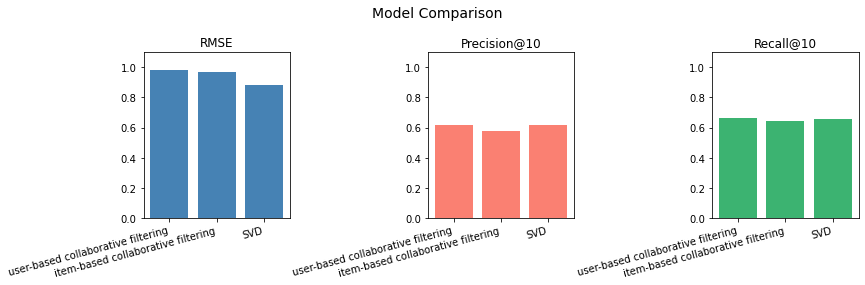

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = ["RMSE", "Precision@10", "Recall@10"]
colors  = ["steelblue", "salmon", "mediumseagreen"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df.index, results_df[metric], color=color)
    ax.set_title(metric)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(results_df.index, rotation=15, ha="right")

plt.suptitle("Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
#best model selection

best_rmse_model = results_df["RMSE"].idxmin()
print("Best model by RMSE:", best_rmse_model)
best_precision_model = results_df["Precision@10"].idxmax()
print("Best model by Precision@10:", best_precision_model)
best_recall_model = results_df["Recall@10"].idxmax()
print("Best model by Recall@10:", best_recall_model)

Best model by RMSE: SVD
Best model by Precision@10: user-based collaborative filtering
Best model by Recall@10: user-based collaborative filtering


# **Task 2**

In [25]:
print(f"Users to recommend: {len(ratings_test)}")

train_users  = set(ratings_train["userId"])
test_users   = set(ratings_test["userId"])
cold_users   = test_users - train_users
known_users  = test_users - cold_users
 
print(f"Known users: {len(known_users)}")
print(f"Cold users: {len(cold_users)} {sorted(cold_users)}")

Users to recommend: 100
Known users: 90
Cold users: 10 [31, 40, 219, 228, 245, 369, 381, 450, 480, 483]


In [26]:
#train SVD on full training set

reader   = Reader(rating_scale=(0.5, 5.0))
data     = Dataset.load_from_df(ratings_train[["userId", "movieId", "rating"]], reader)
trainset = data.build_full_trainset()

svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)

In [27]:
#cold users
popularity = ratings_train.groupby("movieId")["rating"].agg(n_ratings="count", avg_rating="mean").reset_index()

min_votes = 100
min_rating = 4.0

filtered = popularity[(popularity["n_ratings"] >= min_votes) & (popularity["avg_rating"] >= min_rating)]

filtered = filtered.sort_values("avg_rating", ascending=False)

top10_popular = filtered.head(10)["movieId"].tolist()
print(f"Top 10:{top10_popular}")

top10_info = popularity[popularity["movieId"].isin(top10_popular)]
top10_info = top10_info.merge(movies[["movieId", "title_clean"]], on="movieId", how="left")
top10_info = top10_info.set_index("movieId").loc[top10_popular].reset_index()

print(top10_info[["title_clean", "n_ratings", "avg_rating"]].to_string(index=False))

Top 10:[318, 858, 1213, 2959, 1208, 1221, 48516, 58559, 50, 2329]
              title_clean  n_ratings  avg_rating
Shawshank Redemption, The        309    4.423948
           Godfather, The        187    4.299465
               Goodfellas        124    4.266129
               Fight Club        213    4.265258
           Apocalypse Now        102    4.264706
  Godfather: Part II, The        126    4.261905
            Departed, The        103    4.237864
         Dark Knight, The        147    4.234694
      Usual Suspects, The        199    4.233668
       American History X        125    4.228000


In [28]:
#generate recommendations for all users

all_movies = ratings_train["movieId"].unique()
 
recommendations = []
 
for uid in ratings_test["userId"].unique():
 
    if uid in cold_users:
        recs = top10_popular
 
    else:
        rated = set(ratings_train[ratings_train["userId"] == uid]["movieId"])
        unrated = [mid for mid in all_movies if mid not in rated]
 
        preds = [(mid, svd.predict(uid=uid, iid=mid).est) for mid in unrated]
        preds.sort(key=lambda x: x[1], reverse=True)
        recs = [mid for mid, _ in preds[:10]]
 
    recommendations.append([uid] + recs)
    

In [29]:
#fill ratings_test.csv

cols = ["userId"] + [f"recommendation{i}" for i in range(1, 11)]
df = pd.DataFrame(recommendations, columns=cols)

cols_film=cols[1:]
df_long=df.melt(id_vars=['userId'],value_vars=cols_film,var_name='idx',value_name='movieId')
df_merged=pd.merge(df_long,movies,on='movieId',how='left')
output_df=df_merged.pivot(index='userId',columns='idx',values='title_clean').reset_index()


output_df.to_csv("ratings_test_filled.csv", index=False)
 
output_df.head(10)

idx,userId,recommendation1,recommendation10,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9
0,3,Groundhog Day,Gaslight,Goodfellas,Twelve Monkeys (a.k.a. 12 Monkeys),Mr. Holland's Opus,K-PAX,Finding Nemo,Hoop Dreams,"Last Detail, The","Dark Knight, The"
1,7,"Godfather, The","Shawshank Redemption, The","Godfather: Part II, The",All About Eve,12 Angry Men,Raiders of the Lost Ark (Indiana Jones and the...,Toy Story 3,Whiplash,North by Northwest,Schindler's List
2,11,"Matrix, The",Dr. Strangelove or: How I Learned to Stop Worr...,Star Wars: Episode IV - A New Hope,Lawrence of Arabia,Raiders of the Lost Ark (Indiana Jones and the...,Monty Python and the Holy Grail,Goodfellas,Singin' in the Rain,"Godfather, The",Casablanca
3,25,"Usual Suspects, The","Shawshank Redemption, The",Pulp Fiction,Forrest Gump,Fargo,Star Wars: Episode V - The Empire Strikes Back,"Princess Bride, The",Apocalypse Now,Star Wars: Episode VI - Return of the Jedi,Fight Club
4,30,"Usual Suspects, The","Godfather, The","Princess Bride, The","Shining, The",American History X,Fight Club,"Green Mile, The",Amadeus,Dr. Strangelove or: How I Learned to Stop Worr...,Snatch
5,31,"Shawshank Redemption, The",American History X,"Godfather, The",Goodfellas,Fight Club,Apocalypse Now,"Godfather: Part II, The","Departed, The","Dark Knight, The","Usual Suspects, The"
6,40,"Shawshank Redemption, The",American History X,"Godfather, The",Goodfellas,Fight Club,Apocalypse Now,"Godfather: Part II, The","Departed, The","Dark Knight, The","Usual Suspects, The"
7,56,"Streetcar Named Desire, A",Reservoir Dogs,My Neighbor Totoro (Tonari no Totoro),Rear Window,Dr. Strangelove or: How I Learned to Stop Worr...,"Great Escape, The",Lawrence of Arabia,"Grand Day Out with Wallace and Gromit, A","Godfather, The",Snatch
8,64,Dr. Strangelove or: How I Learned to Stop Worr...,Kiss Kiss Bang Bang,"Streetcar Named Desire, A",Evil Dead II (Dead by Dawn),"Philadelphia Story, The",Guess Who's Coming to Dinner,Spirited Away (Sen to Chihiro no kamikakushi),"Grand Day Out with Wallace and Gromit, A",In the Name of the Father,Rear Window
9,71,"Shawshank Redemption, The","Christmas Story, A",Braveheart,Eternal Sunshine of the Spotless Mind,"Streetcar Named Desire, A",Life Is Beautiful (La Vita è bella),"Usual Suspects, The",Goodfellas,Schindler's List,"Shining, The"


In [30]:
#check cold users

output_df[output_df["userId"].isin(cold_users)].head()

idx,userId,recommendation1,recommendation10,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9
5,31,"Shawshank Redemption, The",American History X,"Godfather, The",Goodfellas,Fight Club,Apocalypse Now,"Godfather: Part II, The","Departed, The","Dark Knight, The","Usual Suspects, The"
6,40,"Shawshank Redemption, The",American History X,"Godfather, The",Goodfellas,Fight Club,Apocalypse Now,"Godfather: Part II, The","Departed, The","Dark Knight, The","Usual Suspects, The"
38,219,"Shawshank Redemption, The",American History X,"Godfather, The",Goodfellas,Fight Club,Apocalypse Now,"Godfather: Part II, The","Departed, The","Dark Knight, The","Usual Suspects, The"
39,228,"Shawshank Redemption, The",American History X,"Godfather, The",Goodfellas,Fight Club,Apocalypse Now,"Godfather: Part II, The","Departed, The","Dark Knight, The","Usual Suspects, The"
44,245,"Shawshank Redemption, The",American History X,"Godfather, The",Goodfellas,Fight Club,Apocalypse Now,"Godfather: Part II, The","Departed, The","Dark Knight, The","Usual Suspects, The"
